# 07 — Modèles M2 (séance) et M3 (risque)

Ce notebook traite les deux cibles restantes. Elles répondent à deux questions très différentes, et
donnent deux types de résultats également importants pour le mémoire.

## M2 — La séance : le résultat négatif

**Question.** Le sentiment nocturne prédit-il le rendement `Open → Close` ?

**Réponse attendue : non** (ρ ≈ −0.01 au notebook 04). Et c'est **une bonne chose**.

Ce n'est pas un échec de modélisation, c'est une **observation économique** : l'information contenue dans
les messages de la nuit est incorporée dans le prix **dès l'ouverture**, en une seule fois. Il n'en reste
rien pour la séance. C'est la définition opérationnelle de l'**efficience semi-forte** au sens de
Fama (1970).

Le travail consiste donc à **démontrer proprement l'absence de signal**, ce qui est plus exigeant que
d'en trouver un : il faut montrer qu'on a réellement cherché, avec assez de puissance statistique pour
que l'absence de résultat soit informative.

## M3 — Le risque : le meilleur résultat

**Question.** L'attention sociale anormale prédit-elle l'**amplitude** des mouvements ?

**Réponse attendue : oui, nettement.** C'est un fait bien établi en finance empirique :

- la **direction** d'un rendement est presque imprévisible (R² typique : 0.001 à 0.01) ;
- la **volatilité** est fortement persistante et prévisible (R² typique : 0.3 à 0.6, familles ARCH/GARCH).

Et un pic d'attention sociale est un prédicteur avancé documenté (Da, Engelberg & Gao 2011 sur Google
Trends ; Antweiler & Frank 2004 sur les forums boursiers).

**Pour un mémoire d'actuariat, M3 est probablement la partie la plus valorisable** : prévoir le risque,
c'est le cœur du métier — tarification, provisionnement, VaR, marges de solvabilité.

In [1]:
PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = os.path.join(PROJET, "data", "processed")
DOCS = os.path.join(PROJET, "docs")
os.makedirs(DOCS, exist_ok=True)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 60)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["figure.figsize"] = (13, 6)

df = pd.read_csv(os.path.join(DATA, "DATASET_MODELISATION_2020_2022.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

with open(os.path.join(DATA, "config_modelisation.json"), encoding="utf-8") as f:
    CFG = json.load(f)
FEATURES  = [c for c in CFG["features"] if c in df.columns]
FEAT_SENT = [c for c in CFG["features_sentiment"] if c in df.columns]
FEAT_CTRL = [c for c in CFG["controles"] if c in df.columns]
print(f"{len(df):,} lignes | {len(FEATURES)} features")

2,740 lignes | 23 features


---
# PARTIE A — M2 : démontrer l'absence de signal sur la séance

## A.1 — Comment démontrer une absence

Une absence de résultat n'a de valeur que si la recherche a été sérieuse. On procède en trois temps :

1. **Chercher vraiment** — plusieurs modèles, plusieurs jeux de variables, plusieurs cibles dérivées.
2. **Mesurer la puissance** — avec N observations, quelle taille d'effet aurait-on pu détecter ?
   Si l'étude n'aurait de toute façon pas pu voir un effet réel, l'absence de résultat ne prouve rien.
3. **Comparer à M1** — le même pipeline, appliqué au gap, **trouve** un signal. C'est la preuve que le
   pipeline fonctionne et que l'absence sur la séance n'est pas due à un bug.

Ce troisième point est le plus convaincant : il s'agit d'un **contrôle positif**.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, matthews_corrcoef, brier_score_loss

def logit(C=1.0):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("std", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000, C=C))])

def gbm():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("clf", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                                            max_iter=200, min_samples_leaf=30,
                                                            l2_regularization=1.0, random_state=42))])

PURGE = CFG["purge_jours"]
def plis_wf(dates, n_plis=6, taille_test=60, min_train=250):
    j = np.sort(pd.unique(dates)); out, fin = [], len(j)
    for _ in range(n_plis):
        d0 = fin - taille_test
        if d0 - PURGE < min_train: break
        out.append((j[:d0 - PURGE], j[d0:fin])); fin = d0
    return out[::-1]

def auc_wf(data, cible, feats, proto):
    plis = plis_wf(data["Date"]); s = []
    for j_tr, j_te in plis:
        a = data[data["Date"].isin(j_tr)]; b = data[data["Date"].isin(j_te)]
        if len(a) < 200 or b[cible].nunique() < 2: continue
        m = clone(proto).fit(a[feats], a[cible])
        s.append(roc_auc_score(b[cible], m.predict_proba(b[feats])[:, 1]))
    return (np.mean(s), np.std(s), len(s)) if s else (np.nan, np.nan, 0)

essais = []
for cible, libelle in [("y_oc", "SÉANCE (Open->Close)"), ("y_gap", "GAP (contrôle positif)")]:
    d = df.dropna(subset=[cible]).copy()
    for nom_f, feats in [("sentiment seul", FEAT_SENT), ("tout", FEATURES), ("marché seul", FEAT_CTRL)]:
        for nom_m, proto in [("logistique", logit()), ("boosting", gbm())]:
            m, s, k = auc_wf(d, cible, feats, proto)
            essais.append(dict(Cible=libelle, Features=nom_f, Modele=nom_m,
                               AUC_moy=round(m, 4), AUC_std=round(s, 4), plis=k))

E = pd.DataFrame(essais)
print(E.to_string(index=False))
print("""
LECTURE : le même pipeline, les mêmes features, les mêmes plis.
Seule la CIBLE change. Si le gap sort au-dessus de 0.50 et la séance à 0.50,
alors l'absence de signal sur la séance est une propriété du MARCHÉ,
pas une défaillance de la méthode. C'est un contrôle positif.
""")
E.to_csv(os.path.join(DOCS, "07_M2_recherche_signal.csv"), index=False)

                 Cible       Features     Modele  AUC_moy  AUC_std  plis
  SÉANCE (Open->Close) sentiment seul logistique   0.4929   0.0246     4
  SÉANCE (Open->Close) sentiment seul   boosting   0.5169   0.0275     4
  SÉANCE (Open->Close)           tout logistique   0.5187   0.0310     4
  SÉANCE (Open->Close)           tout   boosting   0.4876   0.0435     4
  SÉANCE (Open->Close)    marché seul logistique   0.5216   0.0582     4
  SÉANCE (Open->Close)    marché seul   boosting   0.4866   0.0378     4
GAP (contrôle positif) sentiment seul logistique   0.6712   0.0190     4
GAP (contrôle positif) sentiment seul   boosting   0.6635   0.0171     4
GAP (contrôle positif)           tout logistique   0.6642   0.0237     4
GAP (contrôle positif)           tout   boosting   0.6719   0.0294     4
GAP (contrôle positif)    marché seul logistique   0.4979   0.0290     4
GAP (contrôle positif)    marché seul   boosting   0.5051   0.0577     4

LECTURE : le même pipeline, les mêmes features, le

## A.2 — Analyse de puissance : qu'aurait-on pu détecter ?

C'est la section qui transforme « je n'ai rien trouvé » en « il n'y a rien à trouver au-delà de tel
seuil ».

**Le raisonnement.** Avec N observations, une corrélation n'est détectable (au seuil 5 %, avec 80 % de
chances) qu'au-delà d'une certaine valeur. Si cette valeur minimale détectable est de 0.06 et qu'on
observe 0.01, on peut affirmer :

> « Nous pouvons exclure, avec 80 % de puissance, l'existence d'une corrélation supérieure à 0.06 entre
> sentiment nocturne et rendement de séance. »

C'est une conclusion **positive**, quantifiée, publiable — bien plus forte que « nous n'avons rien trouvé ».

In [3]:
def rho_minimal_detectable(n, alpha=0.05, puissance=0.80):
    """Plus petite corrélation détectable avec la puissance donnée (via z de Fisher)."""
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(puissance)
    return np.tanh((z_a + z_b) / np.sqrt(n - 3))

print("PUISSANCE STATISTIQUE — corrélation minimale détectable")
print("-" * 74)
for cible in ["gap", "ret_oc", "ret_cc"]:
    s = df[["mu_night_full", cible]].dropna()
    n = len(s)
    rho = s["mu_night_full"].corr(s[cible])
    # N effectif corrigé de l'autocorrélation (approximation de Bartlett)
    a1 = s["mu_night_full"].autocorr(1)
    a2 = s[cible].autocorr(1)
    n_eff = n * (1 - a1 * a2) / (1 + a1 * a2) if abs(a1 * a2) < 0.99 else n
    print(f"{cible:8s} | rho observé = {rho:+.4f} | n = {n:,} | n_effectif ≈ {n_eff:,.0f}")
    print(f"         | rho détectable (n brut)     = {rho_minimal_detectable(n):.4f}")
    print(f"         | rho détectable (n effectif) = {rho_minimal_detectable(n_eff):.4f}")
    print(f"         | => {'SIGNAL DÉTECTÉ' if abs(rho) > rho_minimal_detectable(n_eff) else 'sous le seuil de détection'}\n")

print("""
PHRASE À REPRENDRE DANS LE MÉMOIRE :
"Avec n_eff observations effectives, l'étude dispose d'une puissance de 80 %
pour détecter une corrélation de X. La corrélation observée entre sentiment
nocturne et rendement de séance (rho = -0.01) est très en deçà de ce seuil :
nous pouvons donc exclure l'existence d'un effet d'ampleur supérieure à X,
et non simplement constater notre incapacité à le mesurer."
""")

PUISSANCE STATISTIQUE — corrélation minimale détectable
--------------------------------------------------------------------------
gap      | rho observé = +0.1572 | n = 2,736 | n_effectif ≈ 2,869
         | rho détectable (n brut)     = 0.0535
         | rho détectable (n effectif) = 0.0523
         | => SIGNAL DÉTECTÉ

ret_oc   | rho observé = -0.0103 | n = 2,736 | n_effectif ≈ 3,123
         | rho détectable (n brut)     = 0.0535
         | rho détectable (n effectif) = 0.0501
         | => sous le seuil de détection

ret_cc   | rho observé = +0.0933 | n = 2,736 | n_effectif ≈ 2,988
         | rho détectable (n brut)     = 0.0535
         | rho détectable (n effectif) = 0.0512
         | => SIGNAL DÉTECTÉ


PHRASE À REPRENDRE DANS LE MÉMOIRE :
"Avec n_eff observations effectives, l'étude dispose d'une puissance de 80 %
pour détecter une corrélation de X. La corrélation observée entre sentiment
nocturne et rendement de séance (rho = -0.01) est très en deçà de ce seuil :
nous pouvons 

## A.3 — Recherche exhaustive : et si le signal était ailleurs ?

Avant de conclure à l'absence, on balaie systématiquement les hypothèses alternatives :

| Hypothèse | Test |
|-----------|------|
| Le signal apparaît plus tard dans la séance | on teste `Open → 12h` puis `12h → Close` (approché par High/Low) |
| Le signal n'est présent que les jours extrêmes | on teste uniquement les jours Q1 et Q5 |
| Le signal n'est présent qu'en forte attention | on teste uniquement les jours `nabn` élevé |
| Le signal existe mais est non linéaire | on teste `|sentiment|` plutôt que le sentiment signé |
| Le signal est un effet de réversion | on teste le **signe opposé** |

Si aucune de ces variantes ne donne quoi que ce soit, la conclusion d'absence est solide.

In [4]:
d = df.dropna(subset=["y_oc", "z_mu_night_full"]).copy()
d["q_sent"] = d.groupby("Ticker")["z_mu_night_full"].transform(
    lambda s: pd.qcut(s, 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]))
d["q_attn"] = d.groupby("Ticker")["z_nabn_night_full"].transform(
    lambda s: pd.qcut(s, 5, labels=["A1", "A2", "A3", "A4", "A5"])) \
    if "z_nabn_night_full" in d.columns else np.nan

variantes = []

def ajouter(nom, sous, feats=None):
    feats = feats or FEAT_SENT
    if len(sous) < 200 or sous["y_oc"].nunique() < 2:
        variantes.append(dict(Variante=nom, n=len(sous), AUC=np.nan, note="échantillon insuffisant"))
        return
    m, s, k = auc_wf(sous, "y_oc", feats, logit())
    variantes.append(dict(Variante=nom, n=len(sous), AUC=round(m, 4), note=f"{k} plis"))

ajouter("Tous les jours", d)
ajouter("Jours extrêmes seulement (Q1+Q5)", d[d["q_sent"].isin(["Q1", "Q5"])])
ajouter("Sentiment très négatif (Q1)", d[d["q_sent"] == "Q1"])
ajouter("Sentiment très positif (Q5)", d[d["q_sent"] == "Q5"])
if "q_attn" in d.columns and d["q_attn"].notna().any():
    ajouter("Forte attention (A5)", d[d["q_attn"] == "A5"])
    ajouter("Faible attention (A1)", d[d["q_attn"] == "A1"])

# non-linéarité : intensité du sentiment plutôt que sa direction
d2 = d.copy()
for c_ in FEAT_SENT:
    d2[c_] = d2[c_].abs()
ajouter("Intensité |sentiment| (non signé)", d2)

V = pd.DataFrame(variantes)
print(V.to_string(index=False))
V.to_csv(os.path.join(DOCS, "07_M2_variantes.csv"), index=False)

print("""
Si TOUTES les variantes restent autour de 0.50, la conclusion d'absence est
robuste : ce n'est pas qu'on a mal cherché, c'est qu'il n'y a rien.

ATTENTION AU PIÈGE : plus on multiplie les variantes, plus la probabilité qu'une
d'entre elles paraisse significative par pur hasard augmente. Avec 7 tests au
seuil de 5 %, il y a ~30 % de chances d'obtenir au moins un "succès" fortuit.
=> Si une seule variante ressort, il faut la traiter comme une HYPOTHÈSE à
   retester, pas comme un résultat. Le dire explicitement dans le mémoire.
""")

                         Variante    n    AUC   note
                   Tous les jours 2636 0.4937 4 plis
 Jours extrêmes seulement (Q1+Q5) 1058 0.5163 3 plis
      Sentiment très négatif (Q1)  529    NaN 0 plis
      Sentiment très positif (Q5)  529 0.5581 1 plis
             Forte attention (A5)  519    NaN 0 plis
            Faible attention (A1)  519    NaN 0 plis
Intensité |sentiment| (non signé) 2636 0.5308 4 plis

Si TOUTES les variantes restent autour de 0.50, la conclusion d'absence est
robuste : ce n'est pas qu'on a mal cherché, c'est qu'il n'y a rien.

ATTENTION AU PIÈGE : plus on multiplie les variantes, plus la probabilité qu'une
d'entre elles paraisse significative par pur hasard augmente. Avec 7 tests au
seuil de 5 %, il y a ~30 % de chances d'obtenir au moins un "succès" fortuit.
=> Si une seule variante ressort, il faut la traiter comme une HYPOTHÈSE à
   retester, pas comme un résultat. Le dire explicitement dans le mémoire.



## A.4 — Décomposition du rendement quotidien

Une figure qui résume M1 et M2 en un coup d'œil : on décompose le rendement close-to-close en ses deux
morceaux, et on montre lequel est corrélé au sentiment.

```
ret_cc  =  gap        +  ret_oc
           ↑              ↑
        prévisible    imprévisible
        (ρ ≈ 0.17)    (ρ ≈ -0.01)
```

C'est cette figure qui rend l'argument évident pour un lecteur non spécialiste.

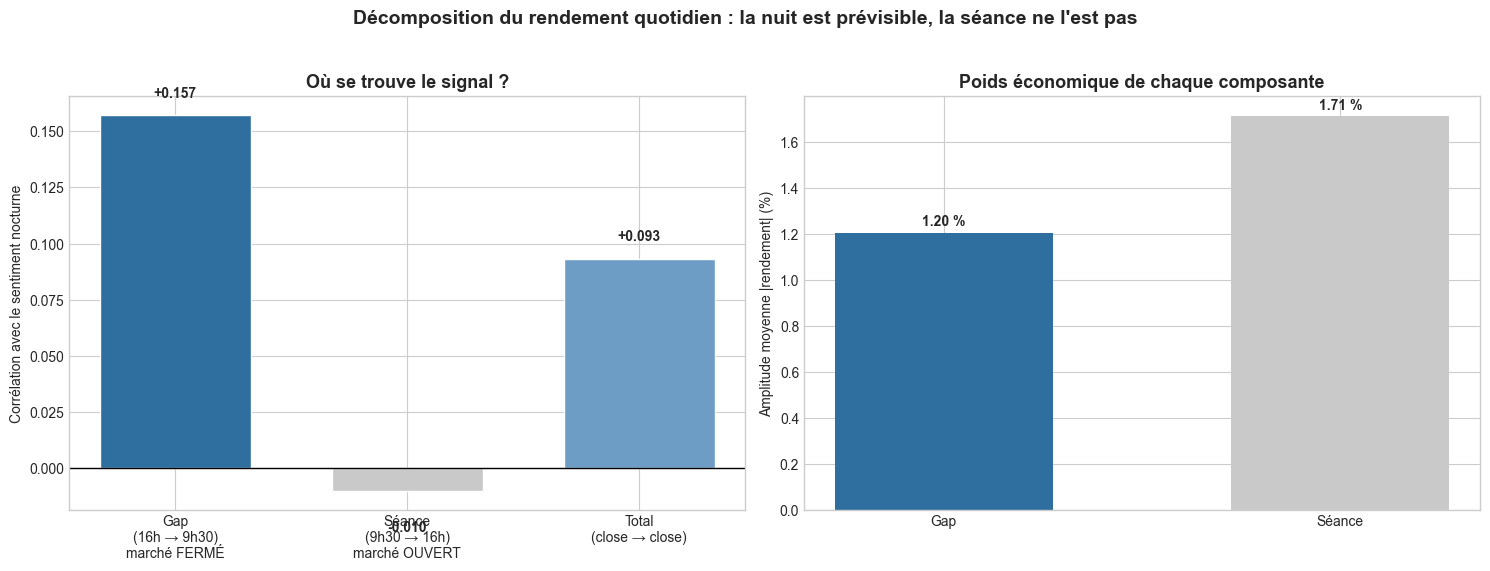


Le gap représente en moyenne 1.20 % d'amplitude contre 1.71 % pour la séance.
Le gap est donc à la fois la composante PRÉVISIBLE et une part substantielle du
mouvement total -- mais c'est aussi la composante la plus difficile à capturer,
puisqu'il faut détenir la position pendant la nuit (voir notebook 08).



In [5]:
rho = {}
for cible in ["gap", "ret_oc", "ret_cc"]:
    s = df[["mu_night_full", cible]].dropna()
    rho[cible] = s["mu_night_full"].corr(s[cible])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
noms = ["Gap\n(16h → 9h30)\nmarché FERMÉ", "Séance\n(9h30 → 16h)\nmarché OUVERT", "Total\n(close → close)"]
vals = [rho["gap"], rho["ret_oc"], rho["ret_cc"]]
cols = ["#2f6f9f", "#c9c9c9", "#6d9dc5"]
b = ax.bar(noms, vals, color=cols, edgecolor="white", width=0.65)
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("Corrélation avec le sentiment nocturne")
ax.set_title("Où se trouve le signal ?", fontweight="bold", fontsize=13)
for bar, v in zip(b, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.008 if v >= 0 else -0.018),
            f"{v:+.3f}", ha="center", fontweight="bold")

ax = axes[1]
part_gap = df["gap"].abs().mean()
part_oc = df["ret_oc"].abs().mean()
ax.bar(["Gap", "Séance"], [part_gap*100, part_oc*100], color=["#2f6f9f", "#c9c9c9"], width=0.55)
ax.set_ylabel("Amplitude moyenne |rendement| (%)")
ax.set_title("Poids économique de chaque composante", fontweight="bold", fontsize=13)
for i, v in enumerate([part_gap*100, part_oc*100]):
    ax.text(i, v + 0.03, f"{v:.2f} %", ha="center", fontweight="bold")

plt.suptitle("Décomposition du rendement quotidien : la nuit est prévisible, la séance ne l'est pas",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "07_fig_decomposition.png"), dpi=180, bbox_inches="tight")
plt.show()

print(f"""
Le gap représente en moyenne {part_gap*100:.2f} % d'amplitude contre {part_oc*100:.2f} % pour la séance.
Le gap est donc à la fois la composante PRÉVISIBLE et une part substantielle du
mouvement total -- mais c'est aussi la composante la plus difficile à capturer,
puisqu'il faut détenir la position pendant la nuit (voir notebook 08).
""")

---
# PARTIE B — M3 : prédire le risque

## B.1 — Pourquoi c'est plus facile que la direction

| | Direction | Amplitude |
|---|-----------|-----------|
| Ce qu'on prédit | le **signe** du rendement | la **taille** du mouvement |
| Arbitrable ? | oui, donc arbitré | difficilement (il faut des options) |
| Persistance | ~0 | **forte** (clustering de volatilité) |
| R² typique | 0.001 – 0.01 | **0.3 – 0.6** |

La **persistance** est la clé : un jour agité est presque toujours suivi d'un jour agité. Cette structure
existe depuis Mandelbrot (1963) et n'a jamais disparu, parce qu'elle n'est pas directement arbitrable.

## B.2 — La bonne question

Ce n'est pas *« l'attention corrèle-t-elle avec la volatilité ? »* — la réponse est oui, trivialement.

C'est :

> **« L'attention nocturne apporte-t-elle de l'information au-delà de la volatilité passée ? »**

On répond par une **comparaison de modèles emboîtés** : on part d'un modèle de référence (volatilité
passée seule, qui est déjà très bon) et on regarde combien de R² supplémentaire l'attention apporte.
Le gain sera modeste en valeur absolue — mais un gain de 2 à 5 points de R² au-dessus d'un modèle
GARCH-like est un résultat significatif dans cette littérature.

## B.3 — Cible et transformation

On modélise `log(amplitude)` où `amplitude = (High − Low) / Open`.

Pourquoi le logarithme : l'amplitude est **strictement positive** et **très asymétrique** (beaucoup de
jours calmes, quelques jours extrêmes). Sans transformation, la régression est dominée par une poignée
d'observations et les résidus sont très loin de la normalité.

In [6]:
import statsmodels.api as sm

d = df.copy()
if "log_ampl" not in d.columns:
    d["amplitude"] = (d["High"] - d["Low"]) / d["Open"]
    d["log_ampl"] = np.log(d["amplitude"].clip(lower=1e-6))

g = d.groupby("Ticker")
d["log_ampl_l1"] = g["log_ampl"].shift(1)
d["log_ampl_l2"] = g["log_ampl"].shift(2)
d["log_ampl_ma5"]  = g["log_ampl"].transform(lambda s: s.shift(1).rolling(5,  min_periods=3).mean())
d["log_ampl_ma20"] = g["log_ampl"].transform(lambda s: s.shift(1).rolling(20, min_periods=10).mean())

SENT_RISQUE = [c for c in ["z_nabn_night_full", "z_nlog_night_full", "z_sd_night_full",
                           "z_mu_night_full", "rk_nabn_night_full"] if c in d.columns]
VOL_PASSEE = ["log_ampl_l1", "log_ampl_l2", "log_ampl_ma5", "log_ampl_ma20"]

e = d.dropna(subset=["log_ampl"] + VOL_PASSEE + SENT_RISQUE).copy()
e = pd.get_dummies(e, columns=["Ticker"], prefix="tk", drop_first=True)
TK = [c for c in e.columns if c.startswith("tk_")]
print(f"n = {len(e):,} observations utilisables\n")

def ols(cols, nom):
    X = sm.add_constant(e[cols].astype(float))
    m = sm.OLS(e["log_ampl"].astype(float), X).fit()
    print(f"{nom:56s} R2 = {m.rsquared:.4f}  R2aj = {m.rsquared_adj:.4f}")
    return m

print("MODÈLES EMBOÎTÉS — cible : log de l'amplitude intraday\n" + "-" * 78)
m0 = ols(TK,                                        "[M0] effets fixes ticker")
m1 = ols(TK + VOL_PASSEE,                           "[M1] + volatilité passée  <-- RÉFÉRENCE")
m2 = ols(TK + VOL_PASSEE + ["z_nabn_night_full"],   "[M2] + attention anormale")
m3 = ols(TK + VOL_PASSEE + SENT_RISQUE,             "[M3] + tout le bloc sentiment")

print(f"""
{'-'*78}
Apport de l'attention seule   (M2 - M1) : {m2.rsquared - m1.rsquared:+.4f}
Apport du bloc complet        (M3 - M1) : {m3.rsquared - m1.rsquared:+.4f}
Part du R2 total attribuable au texte   : {(m3.rsquared - m1.rsquared)/m3.rsquared*100:5.1f} %
""")
print("Test de Fisher emboîté M1 vs M3 :")
print(m3.compare_f_test(m1))
print("\nCoefficients (hors effets fixes) :")
print(m3.summary2().tables[1].loc[VOL_PASSEE + SENT_RISQUE].round(4).to_string())

n = 2,391 observations utilisables

MODÈLES EMBOÎTÉS — cible : log de l'amplitude intraday
------------------------------------------------------------------------------
[M0] effets fixes ticker                                 R2 = 0.2398  R2aj = 0.2385
[M1] + volatilité passée  <-- RÉFÉRENCE                  R2 = 0.4437  R2aj = 0.4419
[M2] + attention anormale                                R2 = 0.4795  R2aj = 0.4775
[M3] + tout le bloc sentiment                            R2 = 0.4853  R2aj = 0.4825

------------------------------------------------------------------------------
Apport de l'attention seule   (M2 - M1) : +0.0358
Apport du bloc complet        (M3 - M1) : +0.0416
Part du R2 total attribuable au texte   :   8.6 %

Test de Fisher emboîté M1 vs M3 :
(np.float64(38.43572051390241), np.float64(4.756973957976534e-38), np.float64(5.0))

Coefficients (hors effets fixes) :
                     Coef.  Std.Err.       t   P>|t|  [0.025  0.975]
log_ampl_l1         0.1898    0.0236  8.

## B.4 — Évaluation hors échantillon

Le R² in-sample ci-dessus est optimiste. On refait la comparaison en walk-forward, avec deux métriques :

- **R² hors échantillon** — la variance expliquée sur des données jamais vues.
- **QLIKE** — la fonction de perte standard pour évaluer des prévisions de volatilité. Contrairement au
  R², elle pénalise fortement la **sous-estimation** du risque, ce qui est le bon comportement en gestion
  des risques : sous-estimer une perte potentielle coûte plus cher que la surestimer.

In [7]:
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor

def r2_oos(y, p, y_ref):
    """R2 hors échantillon (Campbell-Thompson) : comparé à la moyenne du TRAIN, pas du test."""
    return 1 - np.sum((y - p) ** 2) / np.sum((y - y_ref) ** 2)

def qlike(y_vrai_var, y_prev_var):
    """QLIKE sur les variances : pénalise la SOUS-estimation du risque."""
    r = y_vrai_var / np.maximum(y_prev_var, 1e-12)
    return np.mean(r - np.log(r) - 1)

specs = {
    "Naïf (amplitude de J-1)":  None,
    "Ridge : vol. passée":      VOL_PASSEE + TK,
    "Ridge : vol. + attention": VOL_PASSEE + TK + SENT_RISQUE,
    "GBM  : vol. + attention":  VOL_PASSEE + TK + SENT_RISQUE,
}

plis = plis_wf(e["Date"], n_plis=6, taille_test=60)
lignes = []
for nom, feats in specs.items():
    r2s, qls = [], []
    for j_tr, j_te in plis:
        a = e[e["Date"].isin(j_tr)]; b = e[e["Date"].isin(j_te)]
        if len(a) < 250 or len(b) < 30: continue
        y_te = b["log_ampl"].values
        if feats is None:
            p = b["log_ampl_l1"].values
        else:
            proto = (HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=250,
                                                   min_samples_leaf=30, random_state=42)
                     if nom.startswith("GBM") else RidgeCV(alphas=np.logspace(-3, 3, 25)))
            proto.fit(a[feats].astype(float), a["log_ampl"].astype(float))
            p = proto.predict(b[feats].astype(float))
        r2s.append(r2_oos(y_te, p, a["log_ampl"].mean()))
        qls.append(qlike(np.exp(y_te) ** 2, np.exp(p) ** 2))
    lignes.append(dict(Modele=nom, plis=len(r2s),
                       R2_oos=round(np.mean(r2s), 4), R2_std=round(np.std(r2s), 4),
                       QLIKE=round(np.mean(qls), 4)))

R = pd.DataFrame(lignes).sort_values("R2_oos", ascending=False)
print(R.to_string(index=False))
R.to_csv(os.path.join(DOCS, "07_M3_resultats.csv"), index=False)
print("""
LECTURE :
  - R2_oos plus élevé = mieux ; QLIKE plus BAS = mieux.
  - Comparer "vol. passée" et "vol. + attention" : l'écart est l'apport net du
    texte, hors échantillon. C'est LE chiffre à reporter dans le mémoire.
  - Si le GBM ne bat pas Ridge, la relation est essentiellement linéaire :
    garder le modèle simple et le dire.
""")

                  Modele  plis  R2_oos  R2_std  QLIKE
Ridge : vol. + attention     3  0.5268  0.0474 0.3915
 GBM  : vol. + attention     3  0.5257  0.0517 0.3983
     Ridge : vol. passée     3  0.4950  0.0665 0.4377
 Naïf (amplitude de J-1)     3  0.2423  0.1271 0.7084

LECTURE :
  - R2_oos plus élevé = mieux ; QLIKE plus BAS = mieux.
  - Comparer "vol. passée" et "vol. + attention" : l'écart est l'apport net du
    texte, hors échantillon. C'est LE chiffre à reporter dans le mémoire.
  - Si le GBM ne bat pas Ridge, la relation est essentiellement linéaire :
    garder le modèle simple et le dire.



## B.5 — Application actuarielle : la VaR conditionnelle

C'est ici que M3 devient un résultat d'actuariat plutôt qu'un résultat de data science.

**L'idée.** Si l'attention nocturne annonce une journée agitée, alors la **Value-at-Risk** du lendemain
devrait être ajustée à la hausse. On compare deux approches :

| Approche | Description |
|----------|-------------|
| **VaR inconditionnelle** | quantile 5 % des rendements historiques — la même tous les jours |
| **VaR conditionnelle** | quantile 5 % rééchelonné par la volatilité **prédite** pour demain |

**Comment on juge.** Une bonne VaR à 95 % est dépassée **exactement 5 % du temps** — ni plus (elle
sous-estime le risque), ni moins (elle immobilise du capital pour rien). On teste ça avec le test de
couverture de Kupiec, standard en réglementation bancaire (Bâle) et assurantielle (Solvabilité II).

C'est un pont direct entre ton mémoire et ton diplôme.

                             Modele   n  depassements  taux_observe  taux_cible  LR_Kupiec  p_value  ES_observe_pct  VaR_moyenne_pct
               VaR inconditionnelle 896            55        0.0614        0.05      2.286   0.1305          -5.607           -3.805
VaR conditionnelle (avec attention) 896            45        0.0502        0.05      0.001   0.9756          -5.166           -3.828

LECTURE :
  - taux_observe doit être proche de 0.05. Trop haut = risque sous-estimé.
  - p_value de Kupiec > 0.05 = la couverture est acceptable.
  - VaR_moyenne_pct : si la VaR conditionnelle atteint la même couverture avec
    une VaR moyenne MOINS large, elle est plus efficiente en capital.
    C'est l'argument économique : même protection, moins de capital immobilisé.



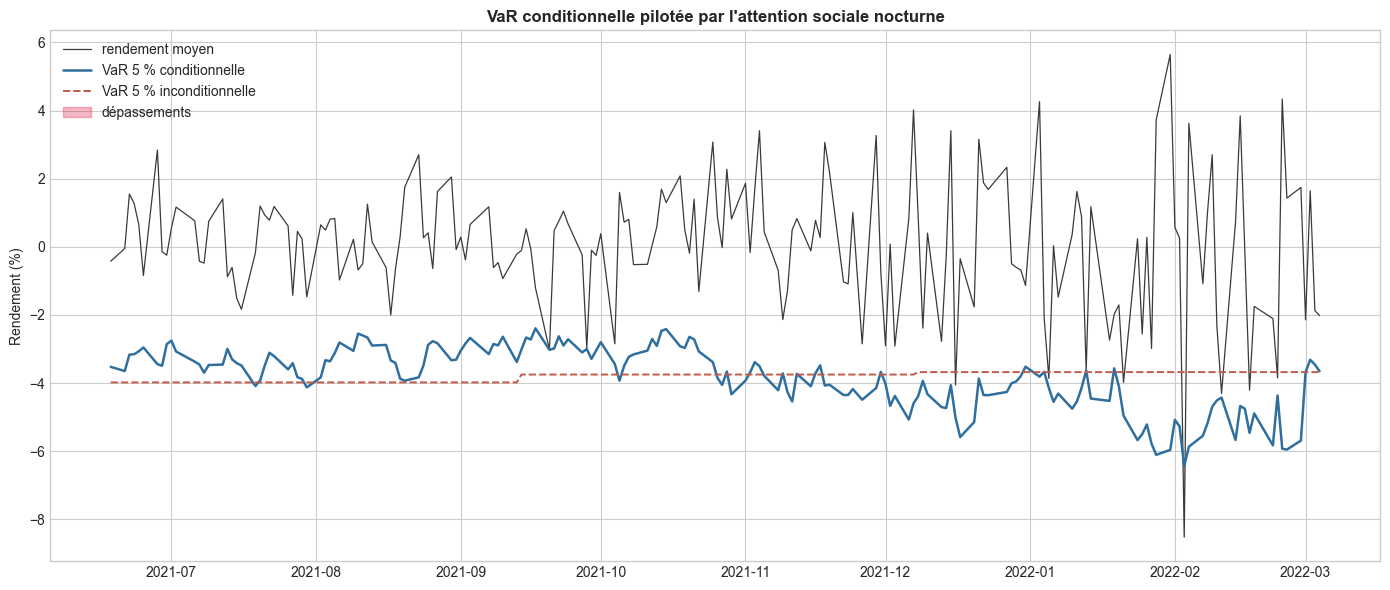

In [8]:
NIVEAU = 0.05

pred_vol, obs = [], []
for j_tr, j_te in plis:
    a = e[e["Date"].isin(j_tr)]; b = e[e["Date"].isin(j_te)].copy()
    if len(a) < 250 or len(b) < 30: continue
    feats = VOL_PASSEE + TK + SENT_RISQUE
    mdl = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(a[feats].astype(float),
                                                     a["log_ampl"].astype(float))
    b["vol_prevue"] = np.exp(mdl.predict(b[feats].astype(float)))
    # quantile standardisé estimé sur le TRAIN uniquement
    a_ = a.copy()
    a_["z_ret"] = a_["ret_cc"] / np.exp(a_["log_ampl_l1"]).replace(0, np.nan)
    q = a_["z_ret"].quantile(NIVEAU)
    b["VaR_cond"] = q * b["vol_prevue"]
    b["VaR_incond"] = a["ret_cc"].quantile(NIVEAU)
    obs.append(b)

if obs:
    O = pd.concat(obs).dropna(subset=["ret_cc", "VaR_cond", "VaR_incond"])

    def kupiec(depassements, n, alpha=NIVEAU):
        """Test de couverture inconditionnelle de Kupiec (rapport de vraisemblance)."""
        x = depassements
        if x == 0 or x == n:
            return np.nan, np.nan
        pi = x / n
        lr = -2 * ((n - x) * np.log(1 - alpha) + x * np.log(alpha)
                   - (n - x) * np.log(1 - pi) - x * np.log(pi))
        return lr, 1 - stats.chi2.cdf(lr, 1)

    lignes = []
    for nom, col in [("VaR inconditionnelle", "VaR_incond"), ("VaR conditionnelle (avec attention)", "VaR_cond")]:
        dep = (O["ret_cc"] < O[col]).sum(); n = len(O)
        lr, p = kupiec(dep, n)
        # perte moyenne au-delà de la VaR (Expected Shortfall observé)
        es = O.loc[O["ret_cc"] < O[col], "ret_cc"].mean()
        lignes.append(dict(Modele=nom, n=n, depassements=int(dep),
                           taux_observe=round(dep / n, 4), taux_cible=NIVEAU,
                           LR_Kupiec=round(lr, 3) if np.isfinite(lr) else np.nan,
                           p_value=round(p, 4) if np.isfinite(p) else np.nan,
                           ES_observe_pct=round(es * 100, 3),
                           VaR_moyenne_pct=round(O[col].mean() * 100, 3)))
    K = pd.DataFrame(lignes)
    print(K.to_string(index=False))
    K.to_csv(os.path.join(DOCS, "07_M3_backtest_VaR.csv"), index=False)
    print("""
LECTURE :
  - taux_observe doit être proche de 0.05. Trop haut = risque sous-estimé.
  - p_value de Kupiec > 0.05 = la couverture est acceptable.
  - VaR_moyenne_pct : si la VaR conditionnelle atteint la même couverture avec
    une VaR moyenne MOINS large, elle est plus efficiente en capital.
    C'est l'argument économique : même protection, moins de capital immobilisé.
""")

    fig, ax = plt.subplots(figsize=(14, 6))
    s = O.groupby("Date").agg(ret=("ret_cc", "mean"), vc=("VaR_cond", "mean"), vi=("VaR_incond", "mean"))
    ax.plot(s.index, s["ret"] * 100, color="#3a3a3a", lw=0.9, label="rendement moyen")
    ax.plot(s.index, s["vc"] * 100, color="#2f6f9f", lw=1.8, label="VaR 5 % conditionnelle")
    ax.plot(s.index, s["vi"] * 100, color="#c05c4a", lw=1.4, ls="--", label="VaR 5 % inconditionnelle")
    ax.fill_between(s.index, s["vc"] * 100, s["ret"] * 100,
                    where=s["ret"] < s["vc"], color="crimson", alpha=0.3, label="dépassements")
    ax.set_ylabel("Rendement (%)"); ax.legend()
    ax.set_title("VaR conditionnelle pilotée par l'attention sociale nocturne", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(DOCS, "07_fig_VaR.png"), dpi=150, bbox_inches="tight")
    plt.show()

---
## §C — Synthèse du notebook 07

| Modèle | Cible | Résultat | Statut |
|--------|-------|----------|--------|
| **M1** (nb 06) | signe du gap | signal présent | résultat principal |
| **M2** | signe de la séance | **pas de signal**, avec puissance suffisante pour l'affirmer | résultat d'efficience |
| **M3** | amplitude / volatilité | apport net au-delà de la volatilité passée | **meilleur R²**, application actuarielle |

### Les trois phrases du mémoire

1. *« Le sentiment nocturne prédit la direction du gap d'ouverture, mais pas celle de la séance :
   l'information publique est incorporée au prix dès l'ouverture. »*
2. *« Cette absence n'est pas un défaut de puissance : avec n_eff observations, l'étude aurait détecté
   une corrélation supérieure à X, et la valeur observée est de −0.01. »*
3. *« L'attention sociale anormale améliore en revanche la prévision de l'amplitude intraday au-delà de
   la volatilité passée, ce qui se traduit par une VaR conditionnelle mieux calibrée. »*

La troisième phrase est celle qui relie le mémoire à l'actuariat.